In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def load_data(file_path):
    if file_path.endswith(".csv"):
        return pd.read_csv(file_path)
    elif file_path.endswith(".xlsx"):
        return pd.read_excel(file_path)
    else:
        raise ValueError("Unsupported file format.")

In [9]:
df = load_data("C:/Users/farih/Documents/ML/diabetes_prediction_dataset.csv")

In [8]:
def perform_eda(df):
    print("Shape: ", df.shape)

    print("Info: ")
    print(df.info())

    print("Missing values: ")
    print(df.isnull().sum())

    print(  "Descriptive statistics: ")
    print(df.describe())

    df.hist(figsize=(12,8))

    # Correlation Heatmap
    numeric_df = df.select_dtypes(include='number')

    if numeric_df.shape[1] > 1:
        import seaborn as sns
        import matplotlib.pyplot as plt

        plt.figure(figsize=(8,6))
        sns.heatmap(numeric_df.corr(),
                    annot=True,
                    cmap='coolwarm')
        plt.show()

    # Boxplots
    numeric_df.plot(kind='box',
                    subplots=True,
                    layout=(len(numeric_df.columns)//3+1,3),
                    figsize=(12,8))


Shape:  (100000, 9)
Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
None
Missing values: 
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes           

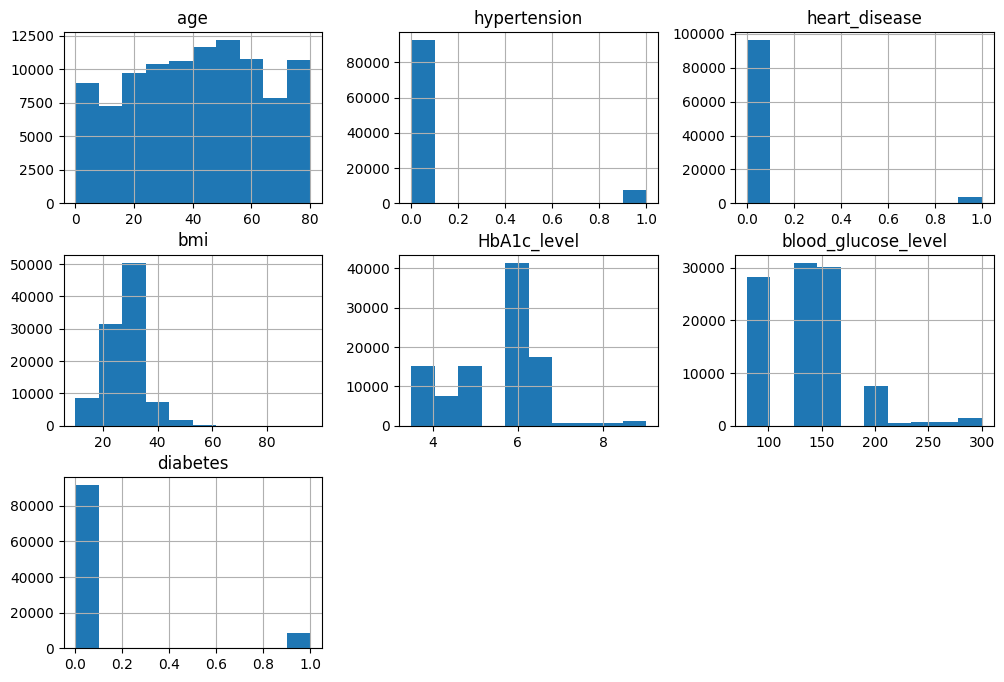

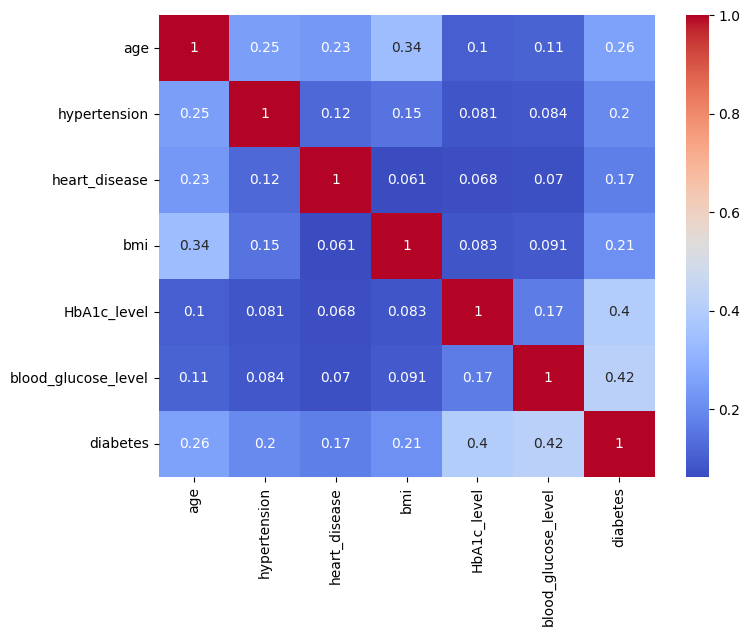

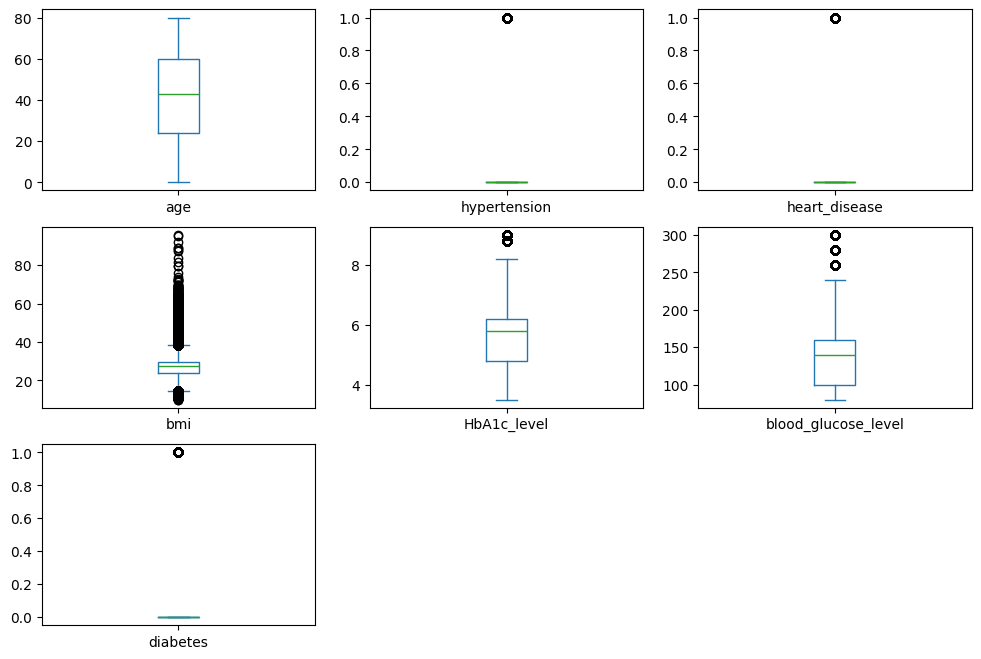

In [10]:
perform_eda(df)

In [11]:
def remove_identifier_columns(df):

    for col in df.columns:

        if df[col].nunique() == len(df):
            df.drop(col, axis=1, inplace=True)

    return df

In [12]:
def preprocess_data(df):

    import pandas as pd
    from sklearn.preprocessing import StandardScaler

    # Separate column types
    numerical_cols = df.select_dtypes(
        include=['int64','float64']
    ).columns

    categorical_cols = df.select_dtypes(
        include=['object']
    ).columns

    # Missing values
    for col in numerical_cols:
        df[col] = df[col].fillna(
            df[col].median()
        )

    for col in categorical_cols:
        df[col] = df[col].fillna(
            df[col].mode()[0]
        )

    # Remove ID-like columns
    for col in df.columns:
        if df[col].nunique() == len(df):
            df.drop(col,
                    axis=1,
                    inplace=True)

    # Encode categorical features
    df = pd.get_dummies(
        df,
        drop_first=True
    )

    # Scale numerical features
    scaler = StandardScaler()

    num_cols = df.select_dtypes(
        include=['int64','float64']
    ).columns

    df[num_cols] = scaler.fit_transform(
        df[num_cols]
    )

    return df